In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             roc_auc_score, f1_score, matthews_corrcoef, balanced_accuracy_score)
from sklearn.metrics import average_precision_score, precision_recall_curve, recall_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('new_data_for_ML-tgShifted.parquet')
df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MG")

Shape: (808940, 231)
Memory: 758.7 MG


In [3]:
for lag in [24, 48, 72, 168]:
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(24).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df['alarm']

# train 60% / val 20% / test 20%
val_idx   = int(len(df) * 0.6)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:val_idx]
X_val   = X.iloc[val_idx:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:val_idx]
y_val   = y.iloc[val_idx:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[val_idx]}")
print(f"Val:   {X_val.shape}: {df['datetime'].iloc[val_idx]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (483045, 227): 2022-03-03 00:00:00 - 2024-07-25 03:00:00
Val:   (161015, 227): 2024-07-25 03:00:00 - 2025-05-16 02:00:00
Test:  (161016, 227): 2025-05-16 02:00:00 - 2026-03-16 23:00:00


In [4]:
tscv = TimeSeriesSplit(n_splits=5)

print("Time Series Cross-Validation:")
print(f"{'Fold':<6} {'Train size':<12} {'Test size':<12} {'ROC-AUC'}")
print("-" * 45)

cv_scores = []
for fold, (train_idx, val_idx_cv) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx_cv]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx_cv]
    
    model_cv = RandomForestClassifier(
        n_estimators=200, max_depth=15,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    model_cv.fit(X_fold_train, y_fold_train)
    y_prob_cv = model_cv.predict_proba(X_fold_val)[:, 1]
    score = roc_auc_score(y_fold_val, y_prob_cv)
    cv_scores.append(score)
    
    print(f"Fold {fold:<4} {len(train_idx):<12} {len(val_idx_cv):<12} {score:.4f}")

print("-" * 45)
print(f"{'Mean':<18} {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Time Series Cross-Validation:
Fold   Train size   Test size    ROC-AUC
---------------------------------------------
Fold 1    80510        80507        0.6756
Fold 2    161017       80507        0.7038
Fold 3    241524       80507        0.7461
Fold 4    322031       80507        0.7556
Fold 5    402538       80507        0.7872
---------------------------------------------
Mean               0.7337 ± 0.0394


In [5]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,  
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [18]:
y_prob_val = model_rf.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_global_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (from validation): {best_global_threshold:.3f}")

X_val_with_meta = X_val.copy()
X_val_with_meta['y_true'] = y_val.values
X_val_with_meta['y_prob'] = y_prob_val

val_start = int(len(df) * 0.6)
X_val_with_meta['region_id'] = df.iloc[val_start:split_idx]['region_id'].values

regional_thresholds = {}
for region in X_val_with_meta['region_id'].unique():
    mask = X_val_with_meta['region_id'] == region
    y_t = X_val_with_meta.loc[mask, 'y_true']
    y_p = X_val_with_meta.loc[mask, 'y_prob']
    
    if y_t.sum() == 0:
        regional_thresholds[region] = best_global_threshold
        continue
    
    best_thresh_reg = 0.05
    for thresh in np.arange(0.70, 0.04, -0.01):
        y_pred = (y_p >= thresh).astype(int)
        r = recall_score(y_t, y_pred, zero_division=0)
        if r >= 0.80:
            best_thresh_reg = round(thresh, 2)
            break
            
    regional_thresholds[region] = best_thresh_reg
    print(f"Region {region:<2}: threshold = {best_thresh_reg:.2f}")

y_prob = model_rf.predict_proba(X_test)[:, 1]

test_regions = df.iloc[split_idx:]['region_id'].values

MIN_THRESHOLD = 0.25
y_pred_final = np.array([
    int(p >= max(regional_thresholds.get(r, best_global_threshold), MIN_THRESHOLD))
    for p, r in zip(y_prob, test_regions)
])

print("\n Final metrics on the TEST ")
print(classification_report(y_test, y_pred_final, target_names=['No Alarm', 'Alarm']))
print(f"Accuracy:          {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:            {average_precision_score(y_test, y_prob):.4f}")
print(f"F1:                {f1_score(y_test, y_pred_final):.4f}")
print(f"MCC:               {matthews_corrcoef(y_test, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_final):.4f}")

Optimal threshold (from validation): 0.564
Region 4 : threshold = 0.59
Region 7 : threshold = 0.19
Region 24: threshold = 0.21
Region 11: threshold = 0.51
Region 23: threshold = 0.48
Region 14: threshold = 0.44
Region 10: threshold = 0.50
Region 25: threshold = 0.51
Region 16: threshold = 0.62
Region 6 : threshold = 0.34
Region 3 : threshold = 0.20
Region 8 : threshold = 0.57
Region 13: threshold = 0.20
Region 21: threshold = 0.44
Region 5 : threshold = 0.70
Region 2 : threshold = 0.30
Region 15: threshold = 0.34
Region 17: threshold = 0.22
Region 19: threshold = 0.21
Region 18: threshold = 0.70
Region 20: threshold = 0.69
Region 22: threshold = 0.27
Region 9 : threshold = 0.20

 Final metrics on the TEST 
              precision    recall  f1-score   support

    No Alarm       0.87      0.47      0.61    114666
       Alarm       0.39      0.82      0.53     46350

    accuracy                           0.57    161016
   macro avg       0.63      0.65      0.57    161016
weighted avg

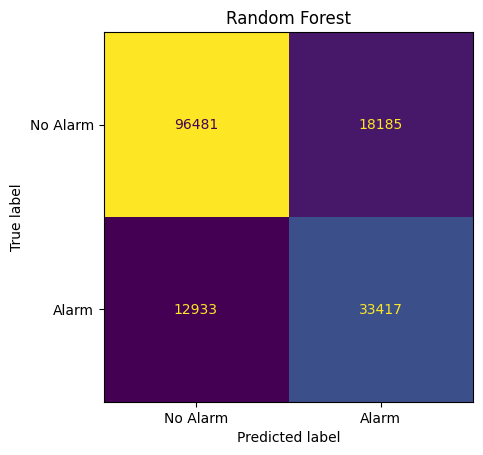

In [7]:
cm = confusion_matrix(y_test, y_pred_final)  
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Alarm', 'Alarm'])
disp.plot(colorbar=False, values_format='d')
plt.title('Random Forest')
plt.show()

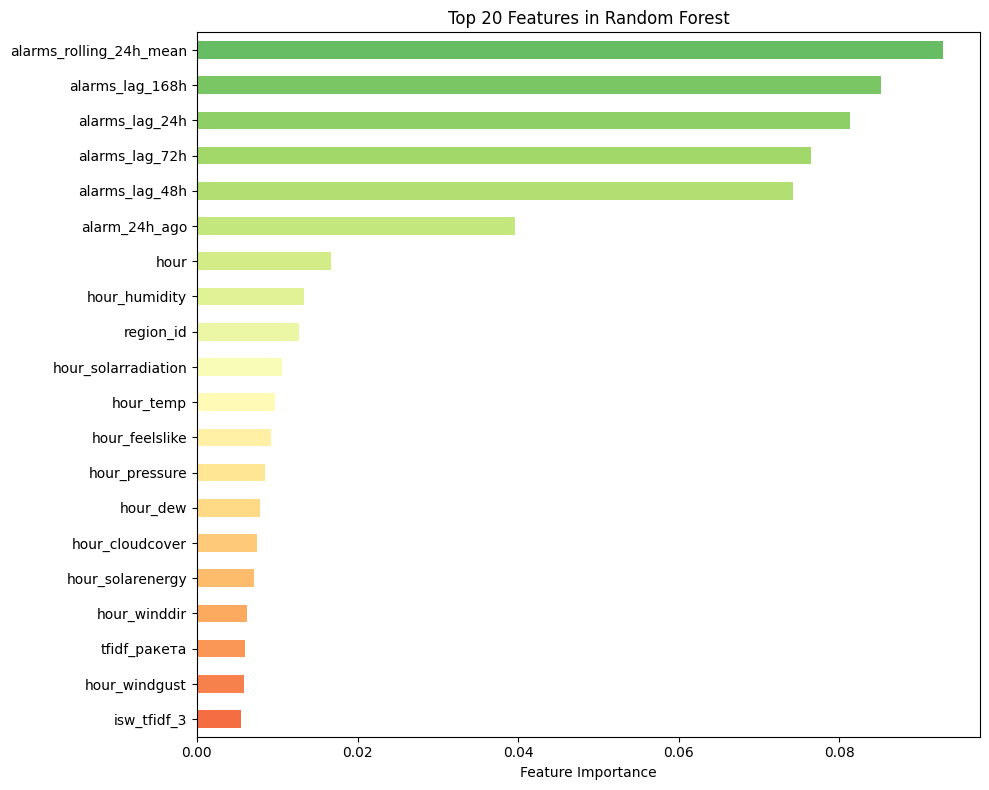

In [10]:
feat_imp = pd.Series(model_rf.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
top20.sort_values().plot(kind='barh', color=colors)
plt.title('Top 20 Features in Random Forest')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [19]:
with open('6__random_forest__v1.pkl', 'wb') as f:
    pickle.dump({
        'model': model_rf,
        'threshold': float(best_global_threshold)
    }, f)